In [8]:
import os
import torch
import numpy as np
import pyexr
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

In [9]:
PITCH = 3.6e-6      # 3.6 micrometers
WAVELENGTH = 638e-9 # 638 nanometers (Red)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def reconstruct_asm(amp, phs, z, pitch=3.6e-6, wavelength=638e-9):
    """Numerical reconstruction using Angular Spectrum Method"""
    res_y, res_x = amp.shape
    # Create complex field: A * exp(j * phi)
    u_hologram = torch.complex(amp * torch.cos(phs), amp * torch.sin(phs))
    
    # FFT to frequency domain
    u_freq = torch.fft.fftshift(torch.fft.fft2(u_hologram))
    
    # Frequency coordinates
    fy = torch.fft.fftfreq(res_y, d=pitch, device=amp.device)
    fx = torch.fft.fftfreq(res_x, d=pitch, device=amp.device)
    fyy, fxx = torch.meshgrid(fy, fx, indexing='ij')
    fyy, fxx = torch.fft.fftshift(fyy), torch.fft.fftshift(fxx)
    
    # Propagation Kernel
    k = 2 * np.pi / wavelength
    term = 1 - (wavelength * fxx)**2 - (wavelength * fyy)**2
    kernel = torch.exp(1j * k * z * torch.sqrt(torch.clamp(term, min=0)))
    
    # Inverse FFT to get reconstructed field
    u_reconstructed = torch.fft.ifft2(torch.fft.ifftshift(u_freq * kernel))
    return torch.abs(u_reconstructed)**2 # Return Intensity

In [ ]:

test_index = "5500"

# Source Paths
path_gt = r"C:\Users\Kai Kumano\workspace\CGH-depth\dataset\KOREATECH-CGH-512-3.6Mu\test"
path_prop = r"C:\Users\Kai Kumano\workspace\CGH-depth\results\engineered_predictions"
# path_base = r"C:\Users\Kai Kumano\workspace\CGH-depth\results\baseline_predictions"

def load_exr_tensor(path):
    """Helper to load EXR and clean it for Torch"""
    data = pyexr.open(path).get().astype(np.float32)
    if data.ndim == 3: data = data[:, :, 0] # Take first channel if RGB
    return torch.from_numpy(data).to(device)

# Load Ground Truth
gt_amp = load_exr_tensor(os.path.join(path_gt, "amp", f"{test_index}.exr"))
gt_phs = load_exr_tensor(os.path.join(path_gt, "phs", f"{test_index}.exr"))

# Load Proposed (Engineered)
prop_amp = load_exr_tensor(os.path.join(path_prop, f"prediction_{test_index}_amp.exr"))
prop_phs = load_exr_tensor(os.path.join(path_prop, f"prediction_{test_index}_phs.exr"))

# Load Baseline
base_amp = load_exr_tensor(os.path.join(path_base, f"prediction_{test_index}_amp.exr"))
base_phs = load_exr_tensor(os.path.join(path_base, f"prediction_{test_index}_phs.exr"))

print(f"Hologram data for index {test_index} loaded successfully.")

Hologram data for index 5500 loaded successfully.


Starting Depth-wise evaluation (PSNR + SSIM)...
Depth 5.0 mm | PSNR: 29.122 dB | SSIM: 0.7905
Depth 10.0 mm | PSNR: 27.684 dB | SSIM: 0.7708
Depth 15.0 mm | PSNR: 27.948 dB | SSIM: 0.7578
Depth 20.0 mm | PSNR: 29.218 dB | SSIM: 0.7731
Depth 25.0 mm | PSNR: 30.634 dB | SSIM: 0.7919


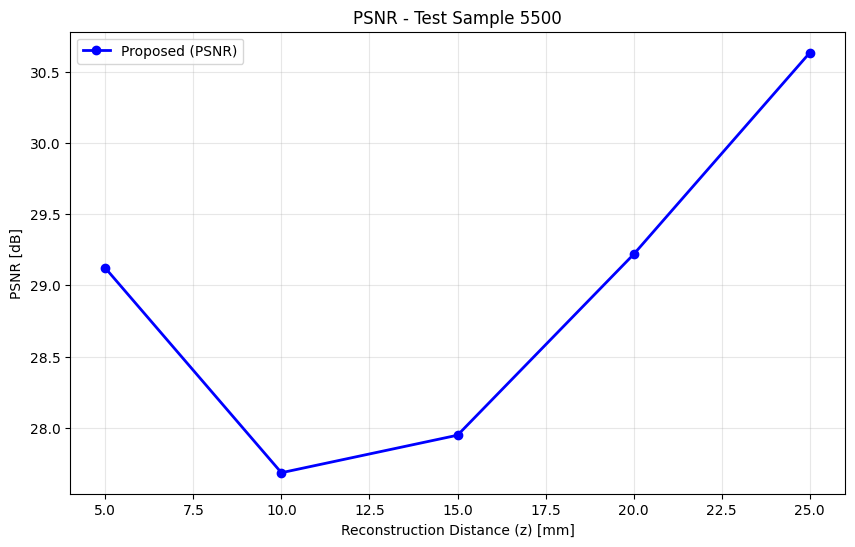

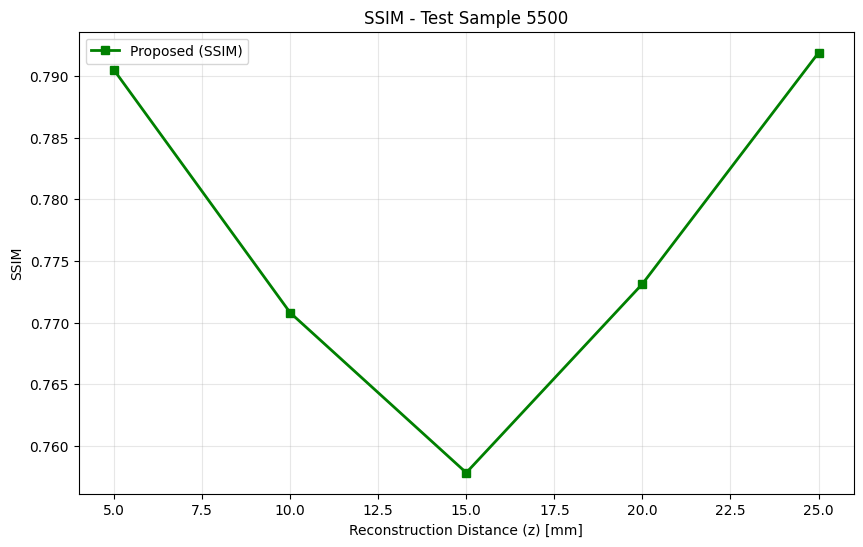

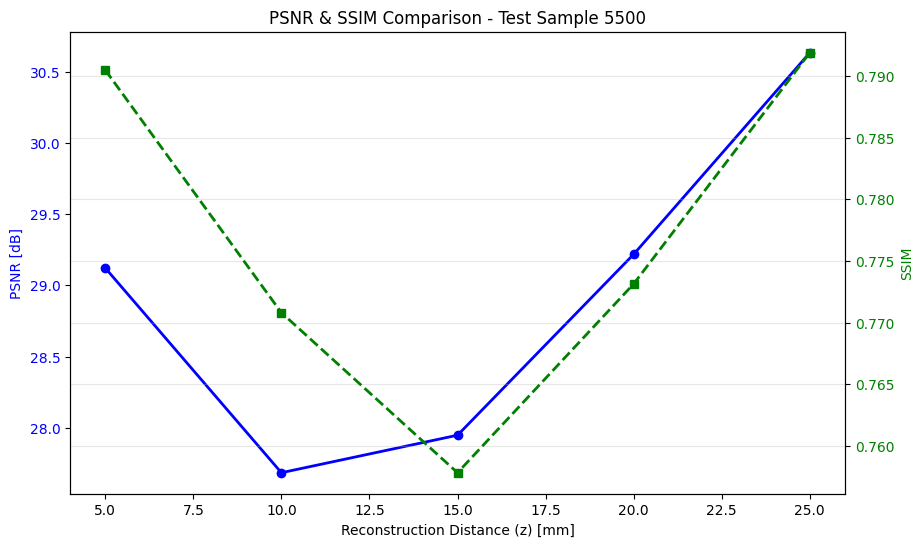

In [ ]:
# -------------------------
# Settings
# -------------------------
depths = [0.005, 0.010, 0.015, 0.020, 0.025]   # 5mm to 25mm

res_prop_psnr = []
res_prop_ssim = []

res_base_psnr = []
res_base_ssim = []


def normalize(img):
    """Normalizes intensity to 0.0-1.0 for fair PSNR/SSIM"""
    img_np = img.detach().cpu().numpy()
    return (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)


print("Starting Depth-wise evaluation for Proposed & Baseline (PSNR + SSIM)...")


# -------------------------
# Main Evaluation Loop
# -------------------------
for z in depths:
    # Propagate GT
    recon_gt = reconstruct_asm(gt_amp, gt_phs, z)

    # Propagate Proposed output
    recon_prop = reconstruct_asm(prop_amp, prop_phs, z)

    # Propagate Baseline output
    recon_base = reconstruct_asm(base_amp, base_phs, z)

    # Normalize for metrics
    gt_norm   = normalize(recon_gt)
    prop_norm = normalize(recon_prop)
    base_norm = normalize(recon_base)

    # ---- PSNR ----
    psnr_p = psnr_metric(gt_norm, prop_norm, data_range=1.0)
    psnr_b = psnr_metric(gt_norm, base_norm, data_range=1.0)

    # ---- SSIM ----
    ssim_p = ssim_metric(gt_norm, prop_norm, data_range=1.0)
    ssim_b = ssim_metric(gt_norm, base_norm, data_range=1.0)

    # Store results
    res_prop_psnr.append(psnr_p)
    res_prop_ssim.append(ssim_p)

    res_base_psnr.append(psnr_b)
    res_base_ssim.append(ssim_b)

    print(f"z = {z*1000:.1f} mm | "
          f"Proposed PSNR={psnr_p:.3f}, SSIM={ssim_p:.4f} | "
          f"Baseline PSNR={psnr_b:.3f}, SSIM={ssim_b:.4f}")


# X-axis (mm)
d_mm = [d * 1000 for d in depths]


# -------------------------
# Plot PSNR: Proposed vs Baseline
# -------------------------
plt.figure(figsize=(10, 6))
plt.plot(d_mm, res_prop_psnr, 'o-', color='blue',  linewidth=2, label='Proposed (PSNR)')
plt.plot(d_mm, res_base_psnr, 's--', color='red', linewidth=2, label='Baseline (PSNR)')

plt.xlabel("Reconstruction Distance (z) [mm]")
plt.ylabel("PSNR [dB]")
plt.title(f"PSNR Comparison - Test Sample {test_index}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# -------------------------
# Plot SSIM: Proposed vs Baseline
# -------------------------
plt.figure(figsize=(10, 6))
plt.plot(d_mm, res_prop_ssim, 'o-', color='green', linewidth=2, label='Proposed (SSIM)')
plt.plot(d_mm, res_base_ssim, 's--', color='orange', linewidth=2, label='Baseline (SSIM)')

plt.xlabel("Reconstruction Distance (z) [mm]")
plt.ylabel("SSIM")
plt.title(f"SSIM Comparison - Test Sample {test_index}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# -------------------------
# Combined Plot (2 metrics × 2 models)
# -------------------------
fig, ax1 = plt.subplots(figsize=(11, 6))

# --- PSNR curves ---
ax1.plot(d_mm, res_prop_psnr, 'o-',  color='blue',  linewidth=2, label='Proposed PSNR')
ax1.plot(d_mm, res_base_psnr, 's--', color='red',   linewidth=2, label='Baseline PSNR')

ax1.set_xlabel("Reconstruction Distance (z) [mm]")
ax1.set_ylabel("PSNR [dB]", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# --- SSIM curves ---
ax2 = ax1.twinx()
ax2.plot(d_mm, res_prop_ssim, 'o-',  color='green',  linewidth=2, label='Proposed SSIM')
ax2.plot(d_mm, res_base_ssim, 's--', color='orange', linewidth=2, label='Baseline SSIM')

ax2.set_ylabel("SSIM", color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title(f"PSNR & SSIM Comparison (Proposed vs Baseline) - Test Sample {test_index}")
plt.grid(True, alpha=0.3)
plt.show()
